# Intro to Neural Shading

Fun exercise!

## 1 - Pick a material

Four are available, each a sphere rendered from 200 cameras under 4 lights. These images are
the **ground truth**, not any model's output.

<table style="border:none;width:100%"><tr style="border:none"><td style="border:none;width:25%;text-align:center;padding:0 6px">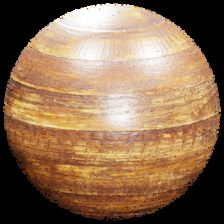<div style="font-size:13.5px;font-weight:700;margin-top:6px">wood_table</div></td><td style="border:none;width:25%;text-align:center;padding:0 6px">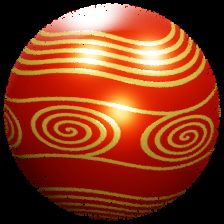<div style="font-size:13.5px;font-weight:700;margin-top:6px">ornament 014</div></td><td style="border:none;width:25%;text-align:center;padding:0 6px">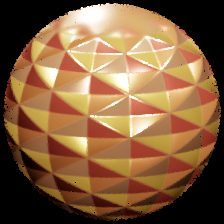<div style="font-size:13.5px;font-weight:700;margin-top:6px">ornament 018</div></td><td style="border:none;width:25%;text-align:center;padding:0 6px">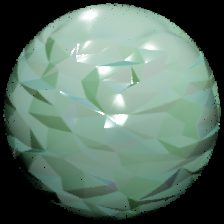<div style="font-size:13.5px;font-weight:700;margin-top:6px">ornament 021</div></td></tr></table>

`wood_table` is nearly diffuse and trains fastest. The ornaments are metallic, with sharp
view-dependent highlights - the hard case for a small network.

In [ ]:
# Set up imports and the device, then download the chosen material (~18 MB).
import os
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")   # only matters on a Mac, not Colab

import math, time, json, urllib.request
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt

MATERIAL = "wood_table"  #@param ["wood_table", "ChristmasTreeOrnament014", "ChristmasTreeOrnament018", "ChristmasTreeOrnament021"]

# A GPU runtime matters here: the work is dominated by kernel launches rather than
# arithmetic, so a CPU runtime gets ~5-10x fewer training steps in the same wall time.
if torch.cuda.is_available():
    DEV = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEV = torch.device("mps")
else:
    DEV = torch.device("cpu")
    print("!! No GPU. Runtime > Change runtime type > T4 GPU, then rerun this cell.")
print("device:", DEV, "| torch", torch.__version__)

# Get the ~18 MB slice for the chosen material. Sources are tried in order: a file already
# beside the notebook, then whatever hosting was configured, then an interactive upload.
DATA_BASE = "https://github.com/Badhri7/Neural_Shading_Intro/releases/download/v1"
DATA_URLS = {}
DRIVE_IDS = {}

NPZ = f"neural_shading_{MATERIAL}.npz"
url = DATA_URLS.get(MATERIAL) or (f"{DATA_BASE}/{NPZ}" if DATA_BASE else "")
drive_id = DRIVE_IDS.get(MATERIAL, "")

if os.path.exists(NPZ):
    print("using the copy already in this session")
elif url:
    print(f"downloading {MATERIAL} ...")
    urllib.request.urlretrieve(url, NPZ)
elif drive_id and not drive_id.startswith("PASTE_"):
    print(f"downloading {MATERIAL} from Drive ...")
    import gdown                                    # preinstalled on Colab
    gdown.download(id=drive_id, output=NPZ, quiet=False)
else:
    # No public host: the file lives somewhere only you can reach (Box, an internal share),
    # so download it in your browser and hand it to this session.
    print(f"Upload {NPZ} - pick it in the dialog below,")
    print("or drag it into the Files pane on the left and rerun this cell.")
    from google.colab import files
    files.upload()

# A host that needs a login hands back an HTML sign-in page instead of the data, and numpy
# would then fail with a confusing "not a zip file". .npz IS a zip, so byte 0 must be "PK".
with open(NPZ, "rb") as _fh:
    if _fh.read(2) != b"PK":
        os.remove(NPZ)
        raise SystemExit(f"{NPZ} is not a valid .npz - the server probably returned a "
                         f"sign-in page. Download it in your browser and upload it here.")
print("data:", NPZ, f"{os.path.getsize(NPZ)/2**20:.1f} MB")

## 2 - Load the dataset

<table style="border:none;width:100%"><tr style="border:none"><td style="border:none;vertical-align:top;padding:0 14px 0 0"><div style="font-size:15px;font-weight:700;margin-bottom:6px">A BRDF, sampled</div><div style="font-size:13.5px;line-height:1.5">Every <b>pixel of every render</b> is one training row:<ul style='margin:6px 0 0 18px;padding:0'><li><code>uv</code> - where on the material</li><li><code>omega_i</code> - toward the light</li><li><code>omega_o</code> - toward the camera</li><li><code>normal</code> - the surface orientation</li><li><code>rgb</code> - what the renderer computed</li></ul></div></td><td style="border:none;width:40%;vertical-align:top"></td></tr></table>

`omega_i` and `omega_o` are not stored - both are derivable, so the next cell rebuilds them:
`omega_i` from the light index, `omega_o` from `pos = centre + R * normal` and the camera.

In [ ]:
# Load the slice, then rebuild the two direction vectors from the geometry.
d = np.load(NPZ, allow_pickle=False)
meta = json.loads(str(d["meta"]))

LIGHT_ENERGY = meta["light_energy"]                              # same for all 4 lights
RADIUS       = meta["sphere_radius"]
CENTRE       = torch.tensor(meta["sphere_centre_rk"], device=DEV)
LIGHT_DIRS   = torch.tensor(d["light_dirs_rk"], device=DEV)      # (4, 3)
CAMPOS       = torch.tensor(d["campos_rk"], device=DEV)          # (200, 3)

uv      = torch.tensor(d["uv"], device=DEV).float()
normal  = F.normalize(torch.tensor(d["normal"], device=DEV).float(), dim=-1)
rgb     = torch.tensor(d["rgb"], device=DEV).float()
cam_i   = torch.tensor(d["cam_idx"], device=DEV).long()
light_i = torch.tensor(d["light_idx"], device=DEV).long()

omega_i = LIGHT_DIRS[light_i]                                    # this row's light direction
pos     = CENTRE[None] + RADIUS * normal                         # its point on the sphere
omega_o = F.normalize(CAMPOS[cam_i] - pos, dim=-1)               # toward its camera

# What the network predicts. rgb = f(...) * Li * cos(theta_i), so dividing out the light
# intensity leaves the part that depends only on the material and the two directions.
# Never tone-map this: the relation is linear, and a shader feeds linear Li at runtime.
target = rgb / LIGHT_ENERGY

# Hold out every 5th camera. The model is only ever scored on cameras it never saw.
is_test    = (cam_i % 5) == 0
train_rows = torch.nonzero(~is_test, as_tuple=True)[0]
test_rows  = torch.nonzero(is_test,  as_tuple=True)[0]

print(f"{meta['material']}: {len(uv):,} rows sampled from {meta['source_rows']:,}")
print(f"train {len(train_rows):,} | held-out {len(test_rows):,} rows")

## 3 - What the model reads, and what it has to reproduce

Four maps - **colour, roughness, metallic, normal** - are 8 scalar channels. That 8-vector per
texel is the entire material input. Nothing in it says how light scatters; that is what the
network has to learn.

In [ ]:
# Load the four maps and stack them into the 8 channels the model reads.
MAPS = {k: torch.tensor(d[f"map_{k}"], device=DEV).float() / 255.0
        for k in ("color", "roughness", "metallic", "normal")}

PBR = torch.cat([MAPS["color"] ** 2.2,             # sRGB -> linear
                 MAPS["roughness"][..., :1],
                 MAPS["metallic"][..., :1],
                 MAPS["normal"] * 2.0 - 1.0],      # [0,1] -> [-1,1]
                dim=-1).permute(2, 0, 1).unsqueeze(0).contiguous()      # (1, 8, H, W)

CH_NAMES = ["colour R", "colour G", "colour B", "roughness",
            "metallic", "normal x", "normal y", "normal z"]

def show_channels(chw, names, title):
    """Show a (C,H,W) tensor as C grayscale panels, each stretched 1-99 percentile."""
    g = chw.detach().cpu().numpy()
    fig, ax = plt.subplots(1, g.shape[0], figsize=(1.6 * g.shape[0], 2.1))
    for c in range(g.shape[0]):
        lo, hi = np.percentile(g[c], 1), np.percentile(g[c], 99)
        ax[c].imshow(np.clip((g[c] - lo) / max(hi - lo, 1e-6), 0, 1), cmap="gray")
        ax[c].set_title(names[c], fontsize=8.5); ax[c].axis("off")
    fig.suptitle(title, fontsize=11); plt.tight_layout(); plt.show()

show_channels(PBR[0], CH_NAMES, "the 8-D input: what a human wrote down about this material")

In [ ]:
# Sample those 8 channels at arbitrary uv - the same bilinear fetch a shader does.
def sample_pbr(uv_batch):
    g = uv_batch.view(1, -1, 1, 2) * 2.0 - 1.0
    out = F.grid_sample(PBR, g, mode="bilinear", padding_mode="border", align_corners=True)
    return out.squeeze(-1).squeeze(0).transpose(0, 1)                   # (B, 8)

print("sampled shape:", tuple(sample_pbr(uv[:5]).shape))

### And this is the target

Held-out cameras, rendered from the dataset itself. This is what the network has to reproduce
from `uv` and two directions.

In [ ]:
# Display helpers: tone mapping, an image renderer, PSNR, and a comparison grid.

def _aces(x):
    return np.clip((x * (2.51*x + 0.03)) / (x * (2.43*x + 0.59) + 0.14), 0, 1)

def tonemap(hdr):
    """HDR radiance -> displayable sRGB. Display only; training stays linear."""
    x = _aces(hdr)
    return np.clip(np.where(x <= 0.0031308, x*12.92,
                            1.055*np.power(np.clip(x, 1e-9, None), 1/2.4) - 0.055), 0, 1)

@torch.no_grad()
def render(cam, model=None, res=112):
    """Image for one camera: ground truth, plus the model's version if one is given.

    Returns (gt, prediction, mask). The 4 lights are accumulated separately and summed,
    which is exact because radiance is linear in the lights.
    """
    fwd = F.normalize(CAMPOS[cam] - CENTRE, dim=-1)
    up_ref = torch.tensor([1., 0., 0.] if abs(float(fwd[1])) > 0.99 else [0., 1., 0.], device=DEV)
    right = F.normalize(torch.cross(up_ref, fwd, dim=-1), dim=-1)
    up = torch.cross(fwd, right, dim=-1)
    gt_img = np.zeros((res, res, 3), np.float32)
    pr_img = np.zeros((res, res, 3), np.float32)
    hit = np.zeros((res, res), bool)

    for k in range(len(LIGHT_DIRS)):
        rows = torch.nonzero((cam_i == cam) & (light_i == k), as_tuple=True)[0]
        if len(rows) == 0:
            continue
        n = normal[rows]
        vis = (n * fwd).sum(-1) > 0.05                        # front-facing samples only
        rows, n = rows[vis], n[vis]
        if len(rows) == 0:
            continue
        # screen position from the geometry (orthographic stand-in for the real camera)
        x = (((n*right).sum(-1)*0.5 + 0.5) * (res-1)).cpu().numpy()
        y = (((n*up).sum(-1)*-0.5 + 0.5) * (res-1)).cpu().numpy()
        vals = [(target[rows] * LIGHT_ENERGY).cpu().numpy()]

        if model is not None:
            oi, oo = to_local(n, omega_i[rows], omega_o[rows])
            pred = model(sample_pbr(uv[rows]), oi, oo)
            lit = ((normal[rows] * omega_i[rows]).sum(-1) > 0).float()[:, None]   # shader does this
            vals.append((pred * lit * LIGHT_ENERGY).cpu().numpy())
        vals = np.concatenate(vals, axis=1)

        # Bilinear splat. Rounding to the nearest pixel would leave ~25% of pixels empty per
        # light, which reads as salt-and-pepper noise once the lights are summed.
        acc = np.zeros((res, res, vals.shape[1]), np.float32)
        w = np.zeros((res, res), np.float32)
        x0, y0 = np.floor(x).astype(np.int64), np.floor(y).astype(np.int64)
        fx, fy = x - x0, y - y0
        for dx, dy, ww in ((0,0,(1-fx)*(1-fy)), (1,0,fx*(1-fy)), (0,1,(1-fx)*fy), (1,1,fx*fy)):
            xi, yi = np.clip(x0+dx, 0, res-1), np.clip(y0+dy, 0, res-1)
            np.add.at(acc, (yi, xi), vals * ww[:, None]); np.add.at(w, (yi, xi), ww)
        occ = w > 1e-6
        den = np.maximum(w, 1e-6)[..., None]
        gt_img += np.where(occ[..., None], acc[..., :3]/den, 0)
        if model is not None:
            pr_img += np.where(occ[..., None], acc[..., 3:]/den, 0)
        hit |= occ
    return gt_img, pr_img, hit

def psnr(pred, gt, mask):
    """Image PSNR in display space, over the object only."""
    mse = float(((tonemap(pred)[mask] - tonemap(gt)[mask]) ** 2).mean())
    return 10 * math.log10(1.0 / max(mse, 1e-12))

def show_gt(cams):
    """Ground truth for a few cameras."""
    fig, ax = plt.subplots(1, len(cams), figsize=(2.3*len(cams), 2.5))
    for a, cam in zip(np.atleast_1d(ax), cams):
        gt, _, m = render(cam)
        a.imshow(tonemap(gt) * m[..., None]); a.set_title(f"cam {cam}", fontsize=9); a.axis("off")
    fig.suptitle("held-out cameras, ground truth", fontsize=11); plt.tight_layout(); plt.show()

show_gt(meta["showcase_cams"])

The dark region on the lowest camera is never reached by any of the 4 lights - no samples exist
there. The odd bright speck is path-tracer noise in the original render.

## 4 - The model

<table style="border:none;width:100%"><tr style="border:none"><td style="border:none;vertical-align:top;padding:0 14px 0 0"><div style="font-size:15px;font-weight:700;margin-bottom:6px">One network</div><div style="font-size:13.5px;line-height:1.5"><code>(material, omega_i, omega_o) -&gt; RGB</code>, evaluated per pixel. This is what stands in for the BRDF.<br><br>A layer is <code>y = Wx + b</code>: a matrix multiply and an add, exactly what you do to a position, except the matrix is not square. The stack is <b>20 -&gt; 64 -&gt; 64 -&gt; 64 -&gt; 3</b>.</div></td><td style="border:none;width:38%;vertical-align:top"></td></tr></table>

The 20 inputs are the 8 material channels plus 12 direction components — each of ω_i and ω_o
expressed in 2 learned bases. The output is `exp(x - 3)`, so radiance cannot come out negative.

In [ ]:
# One network, end to end: (material at this texel, two directions) -> RGB.
MAT_DIM = 8                             # the 8 material channels from section 3
DEC_W, DEC_L, N_FRAMES = 64, 3, 2       # width, hidden layers, learned bases
IN_DIM = MAT_DIM + 6 * N_FRAMES         # 20: the material plus both directions
EPS = 1e-6

def to_local(n, *vecs, eps=1e-6):
    """Express directions in the surface frame (t, b, n). local.z is exactly n . v."""
    up_y = torch.tensor([0., 1., 0.], device=n.device).expand_as(n)
    up_x = torch.tensor([1., 0., 0.], device=n.device).expand_as(n)
    up = torch.where(n[:, 1:2].abs() > 0.99, up_x, up_y)       # avoid n parallel to up
    t = F.normalize(torch.cross(up, n, dim=-1), dim=-1, eps=eps)
    b = torch.cross(n, t, dim=-1)
    return [torch.stack([(t*v).sum(-1), (b*v).sum(-1), (n*v).sum(-1)], -1) for v in vecs]

class NeuralBRDF(nn.Module):
    """(8 PBR channels, omega_i, omega_o) -> rgb / Li.

    activation=False drops every ReLU, which section 7 lets you try.
    """
    def __init__(self, width=DEC_W, layers=DEC_L, n_frames=N_FRAMES, activation=True):
        super().__init__()
        self.n_frames, self.activation = n_frames, activation
        self.frames = nn.Linear(MAT_DIM, 6 * n_frames, bias=False)
        net = [nn.Linear(IN_DIM, width)]
        if activation: net.append(nn.ReLU(True))
        for _ in range(layers - 1):
            net.append(nn.Linear(width, width))
            if activation: net.append(nn.ReLU(True))
        net.append(nn.Linear(width, 3))
        self.net = nn.Sequential(*net)

    def to_input(self, pbr, oi, oo):
        """(material, two directions) -> the flat vector the matmuls actually see."""
        raw = self.frames(pbr).view(-1, self.n_frames, 2, 3)   # (normal, tangent) pairs
        n = F.normalize(raw[:, :, 0], dim=-1, eps=EPS)
        t = raw[:, :, 1]
        t = F.normalize(t - (t * n).sum(-1, keepdim=True) * n, dim=-1, eps=EPS)
        basis = torch.stack([t, torch.cross(n, t, dim=-1), n], dim=-2)   # rows t, b, n
        li = torch.einsum("bnij,bj->bni", basis, oi).flatten(1)
        lo = torch.einsum("bnij,bj->bni", basis, oo).flatten(1)
        return torch.cat([pbr, li, lo], -1)                    # (B, 20)

    def forward(self, pbr, oi, oo):
        return torch.exp(self.net(self.to_input(pbr, oi, oo)) - 3.0)   # radiance is positive

print("parameters (3x64):", sum(p.numel() for p in NeuralBRDF().parameters()))

## 5 - Choose how to measure "wrong"

One number to minimise. It is the only place you say what "wrong" means.

| | |
|---|---|
| **log-L1** | `mean( |log(pred) − log(target)| )` |
| **plain L1** | `mean( |pred − target| )` |
| **MSE on linear** | `mean( (pred − target)² )` |

In [ ]:
# The three candidate losses.
def log_l1(pred, tgt):
    """L1 in log space - equal weight to relative error at any brightness."""
    return (torch.log(pred + EPS) - torch.log(tgt + EPS)).abs().mean()

def l1_linear(pred, tgt):
    """Plain L1 on linear radiance."""
    return (pred - tgt).abs().mean()

def mse_linear(pred, tgt):
    """Squared error on linear radiance - the usual default."""
    return ((pred - tgt) ** 2).mean()

LOSSES = {"log-L1": log_l1, "plain L1": l1_linear, "MSE on linear": mse_linear}

LOSS_NAME = "log-L1"  #@param ["log-L1", "plain L1", "MSE on linear"]
loss_fn = LOSSES[LOSS_NAME]

print(f"selected: {LOSS_NAME}")

## 6 - Choose the size of the network

The decoder runs **per pixel, per light**, so its size is the deployment budget.

- low end `1x16` — 483 parameters
- high end `3x64` — 9,955 parameters, ~20 KB, what this project ships

In [ ]:
# Pick the size of the network.
SHAPE = "3x64"  #@param ["1x16", "1x32", "2x16", "2x32", "2x64", "3x32", "3x64"]

DEC_L, DEC_W = int(SHAPE.split("x")[0]), int(SHAPE.split("x")[1])
print(f"selected: {SHAPE}  ->  {DEC_L} hidden layer(s) of width {DEC_W}")

## 7 - Activation function

<div style="text-align:center"></div>

In [ ]:
# Keep the activation function, or drop it.
ACTIVATION = True  #@param {type:"boolean"}

print(f"Activation function: {'on' if ACTIVATION else 'off'}")

## 8 - Train it

Fixed **step** budget - every configuration gets the same 5,000 steps, so the only thing that
differs is the model.

**Re-run this cell after changing anything above.** Results accumulate in a table.

In [ ]:
# Build the chosen model and train it. Results accumulate across re-runs.
BATCH = 4096
BUDGET_STEPS = 5000        # every run gets this many steps
REPORT_EVERY = 250         # print a line this often

def batch(pool, n=BATCH):
    """A random batch of rows drawn from `pool`."""
    i = pool[torch.randint(0, len(pool), (n,), device=pool.device)]
    return uv[i], omega_i[i], omega_o[i], normal[i], target[i]

def train(model, steps=None, loss_fn=None, tag=""):
    """Train for a fixed number of steps, so every configuration sees the same data."""
    steps = steps or BUDGET_STEPS
    loss_fn = loss_fn or log_l1
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, betas=(0.9, 0.999), eps=1e-7)
    hist, t0, step = [], time.time(), 0
    print(f"{'step':>8} {'loss':>10} {'elapsed':>9}")
    while step < steps:
        b_uv, b_oi, b_oo, b_n, b_tgt = batch(train_rows)
        b_oi, b_oo = to_local(b_n, b_oi, b_oo)           # always in the surface frame
        loss = loss_fn(model(sample_pbr(b_uv), b_oi, b_oo), b_tgt)
        opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
        if step % 100 == 0:
            hist.append((step, loss.item()))
        if step % REPORT_EVERY == 0:
            print(f"{step:>8,} {loss.item():>10.4f} {time.time()-t0:>8.1f}s")
        step += 1
    dt = time.time() - t0
    print(f"{step:>8,} {hist[-1][1]:>10.4f} {dt:>8.1f}s   <- done "
          f"({step/dt:.0f} steps/s)")
    return step, hist

@torch.no_grad()
def held_out_loss(model, n=200_000):
    """log-L1 on cameras never trained on - comparable across all three loss choices."""
    b_uv, b_oi, b_oo, b_n, b_tgt = batch(test_rows, n)
    b_oi, b_oo = to_local(b_n, b_oi, b_oo)
    return log_l1(model(sample_pbr(b_uv), b_oi, b_oo), b_tgt).item()

def show(model, title, cams=None):
    """Ground truth | model | amplified difference, for a few held-out cameras."""
    cams = cams or meta["showcase_cams"]
    fig, ax = plt.subplots(len(cams), 3, figsize=(7, 2.4*len(cams)))
    ax = np.atleast_2d(ax); scores = []
    for r, cam in enumerate(cams):
        gt, pr, m = render(cam, model)
        scores.append(psnr(pr, gt, m))
        ax[r,0].imshow(tonemap(gt)*m[...,None]); ax[r,1].imshow(tonemap(pr)*m[...,None])
        ax[r,2].imshow(np.clip(np.abs(tonemap(pr)-tonemap(gt))*4*m[...,None], 0, 1))
        ax[r,0].set_ylabel(f"cam {cam}\n{scores[-1]:.1f} dB", fontsize=9)
        for c, t in enumerate(("ground truth", "model", "diff x4")):
            ax[r,c].set_xticks([]); ax[r,c].set_yticks([])
            if r == 0: ax[r,c].set_title(t, fontsize=10)
    fig.suptitle(f"{title} - mean {np.mean(scores):.2f} dB"); plt.tight_layout(); plt.show()
    return float(np.mean(scores))

torch.manual_seed(0)
model = NeuralBRDF(width=DEC_W, layers=DEC_L, activation=ACTIVATION).to(DEV)
tag = f"{SHAPE}, {LOSS_NAME}{'' if ACTIVATION else ', no activation'}"
print(f"training: {tag}\n")

STEPS, hist = train(model, steps=BUDGET_STEPS, loss_fn=loss_fn, tag=tag)
PSNR = show(model, tag)

# RESULTS survives re-runs of this cell so configurations can be compared. If it holds rows
# from an older version of the notebook, its columns will not match - start fresh rather than
# failing on a missing key.
COLUMNS = {"shape", "loss", "activation", "steps", "psnr", "held"}
try:
    RESULTS
    if any(set(r) != COLUMNS for r in RESULTS):
        print("(clearing earlier results - they came from a different version of this cell)")
        RESULTS = []
except NameError:
    RESULTS = []
RESULTS.append(dict(shape=SHAPE, loss=LOSS_NAME, activation=ACTIVATION,
                    steps=STEPS, psnr=PSNR, held=held_out_loss(model)))

print(f"\n{'shape':>6} {'loss':>15} {'activ':>6} {'steps':>7} {'PSNR':>7} {'held-out':>9}")
for r in RESULTS:
    print(f"{r['shape']:>6} {r['loss']:>15} {str(r['activation']):>6} {r['steps']:>7,} "
          f"{r['psnr']:>7.2f} {r['held']:>9.4f}")

`held-out` is always log-L1, whatever you trained with, so the three losses stay comparable.

Worth trying:

- Train `3x64` with **MSE on linear** and look at the image, not the number.
- Train `3x64` with the **activation off**. The base colour survives; the highlights do not.
- Train `1x16` with log-L1. Then ask whether the extra 9,472 parameters of `3x64` were worth it.
- Train `2x32` and `3x64` back to back. Same 5,000 steps each — how much of the gap is capacity?

In [ ]:
# The loss curve for the latest run, and whether it generalises to unseen cameras.
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.5, 3.1), gridspec_kw={"width_ratios": [1.7, 1]})
a1.plot(*zip(*hist), lw=1.2, color="#2563eb")
a1.set_yscale("log"); a1.set_xlabel("training step"); a1.set_ylabel(f"{LOSS_NAME} loss")
a1.set_title("what the optimiser saw", fontsize=10); a1.grid(alpha=.3, which="both")

tr, te = hist[-1][1], RESULTS[-1]["held"]
a2.bar([0, 1], [tr, te], 0.5, color=["#9ca3af", "#374151"])
a2.set_xticks([0, 1]); a2.set_xticklabels(["train\n(your loss)", "held-out\n(log-L1)"], fontsize=9)
a2.set_ylabel("loss"); a2.set_title("does it generalise?", fontsize=10)
plt.tight_layout(); plt.show()

## 9 - Two configurations, side by side

Set both, run them, and see the difference rather than remembering a number from three cells
ago. Same seed and the same 5,000 steps for each - so the only difference is the model itself.

In [ ]:
# Train two configurations back to back and put them side by side.
# Each is a full run at the same budget, so this cell takes about 2x a single run.

#@markdown ### Model A
A_shape      = "3x64"    #@param ["1x16", "1x32", "2x16", "2x32", "2x64", "3x32", "3x64"]
A_loss       = "log-L1"  #@param ["log-L1", "plain L1", "MSE on linear"]
A_activation = True      #@param {type:"boolean"}

#@markdown ### Model B
B_shape      = "1x16"    #@param ["1x16", "1x32", "2x16", "2x32", "2x64", "3x32", "3x64"]
B_loss       = "log-L1"  #@param ["log-L1", "plain L1", "MSE on linear"]
B_activation = True      #@param {type:"boolean"}

pair = []
for name, shape, loss_name, act in (("A", A_shape, A_loss, A_activation),
                                    ("B", B_shape, B_loss, B_activation)):
    l, w = int(shape.split("x")[0]), int(shape.split("x")[1])
    torch.manual_seed(0)                                   # same start for both
    m = NeuralBRDF(width=w, layers=l, activation=act).to(DEV)
    label = f"{shape}, {loss_name}{'' if act else ', no activation'}"
    print(f"--- {name}: {label}")
    steps, hist = train(m, steps=BUDGET_STEPS, loss_fn=LOSSES[loss_name], tag=name)
    pair.append(dict(name=name, label=label, model=m, hist=hist, steps=steps,
                     params=sum(p.numel() for p in m.parameters()),
                     held=held_out_loss(m)))
    print()

In [ ]:
# Both models on the same cameras: A on the left, B on the right, ground truth once.
cams = meta["showcase_cams"][:3]
fig, ax = plt.subplots(len(cams), 3, figsize=(7.6, 2.5*len(cams)))
ax = np.atleast_2d(ax)
scores = {p["name"]: [] for p in pair}

for r, cam in enumerate(cams):
    gt, _, m_ = render(cam)
    ax[r, 0].imshow(tonemap(gt) * m_[..., None])
    ax[r, 0].set_ylabel(f"cam {cam}", fontsize=9)
    for c, p in enumerate(pair, start=1):
        _, pr, _ = render(cam, p["model"])
        s = psnr(pr, gt, m_); scores[p["name"]].append(s)
        ax[r, c].imshow(tonemap(pr) * m_[..., None])
        ax[r, c].set_xlabel(f"{s:.1f} dB", fontsize=9)
    for c in range(3):
        ax[r, c].set_xticks([]); ax[r, c].set_yticks([])
        if r == 0:
            ax[r, c].set_title(["ground truth", f"A: {pair[0]['label']}",
                                f"B: {pair[1]['label']}"][c], fontsize=9)
plt.tight_layout(); plt.show()

fig, a1 = plt.subplots(figsize=(5.4, 2.7))
for p, col in zip(pair, ("#2563eb", "#dc2626")):
    a1.plot(*zip(*p["hist"]), lw=1.2, color=col, label=f"{p['name']}: {p['label']}")
a1.set_yscale("log"); a1.set_xlabel("training step"); a1.set_ylabel("loss")
a1.legend(fontsize=8); a1.grid(alpha=.3, which="both")
plt.tight_layout(); plt.show()

print(f"{'':>3} {'config':>28} {'params':>8} {'steps':>7} {'PSNR':>7} {'held-out':>9}")
for p in pair:
    print(f"{p['name']:>3} {p['label']:>28} {p['params']:>8,} {p['steps']:>7,} "
          f"{np.mean(scores[p['name']]):>7.2f} {p['held']:>9.4f}")

In [ ]:
# What you would actually ship for each of these two models.
def shipping_size(m):
    """Per-tensor breakdown of everything inference needs."""
    rows, total = [], 0
    for k, v in m.state_dict().items():
        rows.append((k, tuple(v.shape), v.numel()))
        total += v.numel()
    return rows, total

for p in pair:
    rows, total = shipping_size(p["model"])
    print(f"--- {p['name']}: {p['label']}")
    print(f"    {'tensor':<14} {'shape':<12} {'floats':>8}")
    for k, shp, n in rows:
        print(f"    {k:<14} {str(shp):<12} {n:>8,}")
    print(f"    {'':<14} {'TOTAL':<12} {total:>8,}   "
          f"= {total*2/1024:6.1f} KB fp16   {total*4/1024:6.1f} KB fp32")
    print()

a, b = pair[0], pair[1]
ta = sum(v.numel() for v in a["model"].state_dict().values())
tb = sum(v.numel() for v in b["model"].state_dict().values())
print(f"{a['name']} ships {ta*2/1024:.1f} KB, {b['name']} ships {tb*2/1024:.1f} KB "
      f"-> {ta/tb:.1f}x")
print(f"and buys {np.mean(scores[a['name']]) - np.mean(scores[b['name']]):+.2f} dB")
print()
print("Every one of those tensors becomes a buffer the shader reads. The weight matrices are")
print("the two nested loops in the fragment shader; the biases are the value each output")
print("starts from. Nothing else from this notebook ships - no optimiser, no training data,")
print("no PyTorch.")

## What to take away

1. **A layer is a transform.** `y = Wx + b` is a matrix multiply and an add; a network is a stack
   of them.
2. **The activation function is what makes depth mean anything.** Without it every layer is just a
   matrix multiply, and multiplying matrices gives you one matrix.
3. **The loss is a statement about which errors you accept.** The model takes you at your word.
4. **Capacity is a budget, not a virtue.** This decoder runs per pixel, per light.
5. **A trained model is a data structure** - a few thousand numbers and a handful of matmuls.

Things to try:

- Each of the three losses, looking at the images rather than the numbers.
- `1x16` against `3x64`, and decide whether the extra parameters earned their place.
- Turn the activation off and watch the highlights go.
- A different material in section 1: the metallic ornaments punish a small network far harder
  than the wood does.